In [2]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd
counts = pd.read_csv('datasetWhiteMerged.csv')
counts

,Ensembl_ID,TCGA-J9-A8CN-01A,TCGA-HC-7078-01A,TCGA-VN-A88K-01A,TCGA-2A-A8VL-01A,TCGA-HC-7821-01A,TCGA-J4-A67K-01A,TCGA-ZG-A9LN-01A,TCGA-M7-A721-01A,TCGA-V1-A9OH-01A,...,TCGA-EJ-7792-11A,TCGA-CH-5761-11A,TCGA-HC-7752-11A,TCGA-HC-7738-11A,TCGA-HC-7747-11A,TCGA-EJ-7314-11A,TCGA-EJ-7784-11A,TCGA-HC-7211-11A,TCGA-EJ-7785-11A,TCGA-G9-6384-11A
0,ENSG00000000003.13,10.900867,11.216140,11.270879,11.485829,11.505315,11.758223,10.633903,12.144021,11.179287,...,11.896711,11.934428,11.252074,9.769838,10.632086,11.239599,12.639793,9.779719,12.060696,11.748612
1,ENSG00000000005.5,1.000000,3.169925,2.321928,2.807355,2.000000,0.000000,2.000000,3.700440,2.321928,...,2.807355,3.906891,6.523562,8.016808,8.994353,2.584963,4.643856,8.092757,4.906891,5.832890
2,ENSG00000000419.11,9.911392,10.199672,10.619303,10.404077,10.742309,10.347621,10.574594,10.238405,10.022368,...,10.672425,10.186114,10.158610,10.036174,10.510764,10.263269,11.095397,10.232421,11.133142,10.187352
3,ENSG00000000457.12,8.945444,9.736402,10.158610,9.902375,10.193525,9.688250,9.614710,9.779719,9.055282,...,10.554589,9.906891,9.642052,9.290019,9.851749,9.874981,10.926296,9.036174,10.513728,9.541097
4,ENSG00000000460.15,6.700440,7.761551,7.774787,6.906891,7.781360,7.303781,7.888743,7.312883,6.614710,...,8.005625,7.442943,7.523562,6.918863,7.426265,7.721099,8.290019,7.044394,8.271463,7.159871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60483,__no_feature,21.649725,22.315469,21.548756,21.686189,21.995840,21.156766,21.301284,21.307257,20.568851,...,21.084396,21.208938,21.525098,21.373263,21.410451,20.769651,21.573926,21.538965,21.471675,21.104635
60484,__ambiguous,20.870979,21.135762,21.125168,20.936525,21.144389,21.602553,21.112067,20.935761,20.762707,...,20.957352,20.844589,21.146756,20.490322,21.036579,20.795978,21.314629,20.704741,21.212581,20.989337
60485,__too_low_aQual,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60486,__not_aligned,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [3]:
counts = counts.set_index('Ensembl_ID')
counts

,TCGA-J9-A8CN-01A,TCGA-HC-7078-01A,TCGA-VN-A88K-01A,TCGA-2A-A8VL-01A,TCGA-HC-7821-01A,TCGA-J4-A67K-01A,TCGA-ZG-A9LN-01A,TCGA-M7-A721-01A,TCGA-V1-A9OH-01A,TCGA-HC-A8D0-01A,...,TCGA-EJ-7792-11A,TCGA-CH-5761-11A,TCGA-HC-7752-11A,TCGA-HC-7738-11A,TCGA-HC-7747-11A,TCGA-EJ-7314-11A,TCGA-EJ-7784-11A,TCGA-HC-7211-11A,TCGA-EJ-7785-11A,TCGA-G9-6384-11A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.13,10.900867,11.216140,11.270879,11.485829,11.505315,11.758223,10.633903,12.144021,11.179287,11.609640,...,11.896711,11.934428,11.252074,9.769838,10.632086,11.239599,12.639793,9.779719,12.060696,11.748612
ENSG00000000005.5,1.000000,3.169925,2.321928,2.807355,2.000000,0.000000,2.000000,3.700440,2.321928,3.321928,...,2.807355,3.906891,6.523562,8.016808,8.994353,2.584963,4.643856,8.092757,4.906891,5.832890
ENSG00000000419.11,9.911392,10.199672,10.619303,10.404077,10.742309,10.347621,10.574594,10.238405,10.022368,10.321928,...,10.672425,10.186114,10.158610,10.036174,10.510764,10.263269,11.095397,10.232421,11.133142,10.187352
ENSG00000000457.12,8.945444,9.736402,10.158610,9.902375,10.193525,9.688250,9.614710,9.779719,9.055282,9.688250,...,10.554589,9.906891,9.642052,9.290019,9.851749,9.874981,10.926296,9.036174,10.513728,9.541097
ENSG00000000460.15,6.700440,7.761551,7.774787,6.906891,7.781360,7.303781,7.888743,7.312883,6.614710,7.562242,...,8.005625,7.442943,7.523562,6.918863,7.426265,7.721099,8.290019,7.044394,8.271463,7.159871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
__no_feature,21.649725,22.315469,21.548756,21.686189,21.995840,21.156766,21.301284,21.307257,20.568851,21.014955,...,21.084396,21.208938,21.525098,21.373263,21.410451,20.769651,21.573926,21.538965,21.471675,21.104635
__ambiguous,20.870979,21.135762,21.125168,20.936525,21.144389,21.602553,21.112067,20.935761,20.762707,20.702904,...,20.957352,20.844589,21.146756,20.490322,21.036579,20.795978,21.314629,20.704741,21.212581,20.989337
__too_low_aQual,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
counts = counts.round()
counts = counts.astype(int)
counts

,TCGA-J9-A8CN-01A,TCGA-HC-7078-01A,TCGA-VN-A88K-01A,TCGA-2A-A8VL-01A,TCGA-HC-7821-01A,TCGA-J4-A67K-01A,TCGA-ZG-A9LN-01A,TCGA-M7-A721-01A,TCGA-V1-A9OH-01A,TCGA-HC-A8D0-01A,...,TCGA-EJ-7792-11A,TCGA-CH-5761-11A,TCGA-HC-7752-11A,TCGA-HC-7738-11A,TCGA-HC-7747-11A,TCGA-EJ-7314-11A,TCGA-EJ-7784-11A,TCGA-HC-7211-11A,TCGA-EJ-7785-11A,TCGA-G9-6384-11A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.13,11,11,11,11,12,12,11,12,11,12,...,12,12,11,10,11,11,13,10,12,12
ENSG00000000005.5,1,3,2,3,2,0,2,4,2,3,...,3,4,7,8,9,3,5,8,5,6
ENSG00000000419.11,10,10,11,10,11,10,11,10,10,10,...,11,10,10,10,11,10,11,10,11,10
ENSG00000000457.12,9,10,10,10,10,10,10,10,9,10,...,11,10,10,9,10,10,11,9,11,10
ENSG00000000460.15,7,8,8,7,8,7,8,7,7,8,...,8,7,8,7,7,8,8,7,8,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
__no_feature,22,22,22,22,22,21,21,21,21,21,...,21,21,22,21,21,21,22,22,21,21
__ambiguous,21,21,21,21,21,22,21,21,21,21,...,21,21,21,20,21,21,21,21,21,21
__too_low_aQual,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
total_zeros = (counts == 0).sum().sum()
print(f"Total zero values: {total_zeros}")



Total zero values: 13034188


In [ ]:
counts = counts[counts.sum(axis = 1) > 0]
counts

,TCGA-J9-A8CN-01A,TCGA-HC-7078-01A,TCGA-VN-A88K-01A,TCGA-2A-A8VL-01A,TCGA-HC-7821-01A,TCGA-J4-A67K-01A,TCGA-ZG-A9LN-01A,TCGA-M7-A721-01A,TCGA-V1-A9OH-01A,TCGA-HC-A8D0-01A,...,TCGA-EJ-7792-11A,TCGA-CH-5761-11A,TCGA-HC-7752-11A,TCGA-HC-7738-11A,TCGA-HC-7747-11A,TCGA-EJ-7314-11A,TCGA-EJ-7784-11A,TCGA-HC-7211-11A,TCGA-EJ-7785-11A,TCGA-G9-6384-11A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.13,11,11,11,11,12,12,11,12,11,12,...,12,12,11,10,11,11,13,10,12,12
ENSG00000000005.5,1,3,2,3,2,0,2,4,2,3,...,3,4,7,8,9,3,5,8,5,6
ENSG00000000419.11,10,10,11,10,11,10,11,10,10,10,...,11,10,10,10,11,10,11,10,11,10
ENSG00000000457.12,9,10,10,10,10,10,10,10,9,10,...,11,10,10,9,10,10,11,9,11,10
ENSG00000000460.15,7,8,8,7,8,7,8,7,7,8,...,8,7,8,7,7,8,8,7,8,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000281920.1,1,0,1,0,0,3,2,2,0,0,...,2,0,3,1,2,1,0,0,2,4
ENSG00000281921.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
__no_feature,22,22,22,22,22,21,21,21,21,21,...,21,21,22,21,21,21,22,22,21,21


In [ ]:
counts = counts.T
counts

Ensembl_ID,ENSG00000000003.13,ENSG00000000005.5,ENSG00000000419.11,ENSG00000000457.12,ENSG00000000460.15,ENSG00000000938.11,ENSG00000000971.14,ENSG00000001036.12,ENSG00000001084.9,ENSG00000001167.13,...,ENSG00000281906.1,ENSG00000281909.1,ENSG00000281910.1,ENSG00000281912.1,ENSG00000281918.1,ENSG00000281920.1,ENSG00000281921.1,__no_feature,__ambiguous,__alignment_not_unique
TCGA-J9-A8CN-01A,11,1,10,9,7,8,8,12,11,10,...,2,2,0,6,2,1,0,22,21,25
TCGA-HC-7078-01A,11,3,10,10,8,9,10,11,12,12,...,4,1,0,7,3,0,0,22,21,25
TCGA-VN-A88K-01A,11,2,11,10,8,8,10,12,12,11,...,0,2,0,6,1,1,0,22,21,25
TCGA-2A-A8VL-01A,11,3,10,10,7,7,8,12,11,11,...,2,2,0,7,2,0,0,22,21,24
TCGA-HC-7821-01A,12,2,11,10,8,9,10,11,11,11,...,1,2,0,7,2,0,0,22,21,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-EJ-7314-11A,11,3,10,10,8,8,11,11,12,11,...,1,0,0,6,0,1,0,21,21,23
TCGA-EJ-7784-11A,13,5,11,11,8,9,12,12,13,11,...,0,0,1,7,1,0,0,22,21,24
TCGA-HC-7211-11A,10,8,10,9,7,6,8,12,11,10,...,0,2,0,7,2,0,0,22,21,24
TCGA-EJ-7785-11A,12,5,11,11,8,8,12,11,12,11,...,0,0,1,7,1,2,0,21,21,24


In [ ]:
conditions = ['cancer' if '-01' in sample else 'normal' for sample in counts.index]
metadata = pd.DataFrame({'Sample': counts.index, 'Condition': conditions})
metadata = metadata.set_index('Sample')
metadata

,Condition
Sample,
TCGA-J9-A8CN-01A,cancer
TCGA-HC-7078-01A,cancer
TCGA-VN-A88K-01A,cancer
TCGA-2A-A8VL-01A,cancer
TCGA-HC-7821-01A,cancer
...,...
TCGA-EJ-7314-11A,normal
TCGA-EJ-7784-11A,normal
TCGA-HC-7211-11A,normal


In [ ]:
dds = DeseqDataSet(counts=counts,
            metadata=metadata,
            design_factors="Condition")

In [ ]:
dds.deseq2()

Fitting size factors...
... done in 1.46 seconds.

Fitting dispersions...
... done in 181.24 seconds.

Fitting dispersion trend curve...
c:\Users\jheno\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydeseq2\dds.py:716: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 2.05 seconds.

Fitting MAP dispersions...
... done in 251.62 seconds.

Fitting LFCs...
... done in 5.79 seconds.

Calculating cook's distance...
... done in 4.47 seconds.

Replacing 0 outlier genes.



In [ ]:
dds

AnnData object with n_obs × n_vars = 458 × 57429
    obs: 'Condition'
    uns: 'mean_disp', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [ ]:
stat_res = DeseqStats(dds, contrast = ('Condition','cancer','normal'))

In [ ]:
stat_res.summary()

Running Wald tests...
... done in 14.96 seconds.



Log2 fold change & Wald test p-value: Condition cancer vs normal
                         baseMean  log2FoldChange     lfcSE      stat  \
Ensembl_ID                                                              
ENSG00000000003.13      11.638780        0.000501  0.066638  0.007520   
ENSG00000000005.5        2.788120       -0.944514  0.124067 -7.612954   
ENSG00000000419.11      10.415507       -0.005559  0.070313 -0.079058   
ENSG00000000457.12       9.906853       -0.004474  0.072101 -0.062051   
ENSG00000000460.15       7.620172       -0.012608  0.082001 -0.153752   
...                           ...             ...       ...       ...   
ENSG00000281920.1        1.640737       -0.322981  0.163404 -1.976577   
ENSG00000281921.1        0.017062       -0.065231  4.012066 -0.016259   
__no_feature            21.466824        0.033782  0.049553  0.681719   
__ambiguous             20.996061        0.025807  0.049992  0.516219   
__alignment_not_unique  23.986336        0.014699  0.046637

In [ ]:
res = stat_res.results_df
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ensembl_ID,,,,,,
ENSG00000000003.13,11.638780,0.000501,0.066638,0.007520,9.939996e-01,9.984950e-01
ENSG00000000005.5,2.788120,-0.944514,0.124067,-7.612954,2.679010e-14,8.186075e-12
ENSG00000000419.11,10.415507,-0.005559,0.070313,-0.079058,9.369869e-01,9.883094e-01
ENSG00000000457.12,9.906853,-0.004474,0.072101,-0.062051,9.505223e-01,9.903472e-01
ENSG00000000460.15,7.620172,-0.012608,0.082001,-0.153752,8.778051e-01,9.785556e-01
...,...,...,...,...,...,...
ENSG00000281920.1,1.640737,-0.322981,0.163404,-1.976577,4.808942e-02,2.056070e-01
ENSG00000281921.1,0.017062,-0.065231,4.012066,-0.016259,9.870280e-01,NaN
__no_feature,21.466824,0.033782,0.049553,0.681719,4.954166e-01,8.383453e-01


In [ ]:
# res.to_csv('degs.csv')

In [ ]:
from sanbomics.tools import id_map

In [ ]:
mapper = id_map(species = 'human')

In [ ]:
res = res[(res.padj < 0.05) & (res.baseMean >= 10)]
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ensembl_ID,,,,,,
ENSG00000004468.11,10.093976,-0.270730,0.066669,-4.060815,4.890173e-05,8.839274e-04
ENSG00000004776.10,11.061016,-0.217283,0.064436,-3.372055,7.460954e-04,8.287772e-03
ENSG00000004799.7,11.398823,-0.230008,0.063264,-3.635671,2.772581e-04,3.686020e-03
ENSG00000006118.13,11.107131,0.223163,0.072641,3.072130,2.125370e-03,1.931293e-02
ENSG00000012223.11,12.804309,-0.205982,0.060620,-3.397931,6.789759e-04,7.702195e-03
...,...,...,...,...,...,...
ENSG00000242125.3,10.420823,0.238033,0.075353,3.158902,1.583648e-03,1.524682e-02
ENSG00000242899.1,11.231464,0.436596,0.076896,5.677730,1.364943e-08,8.262839e-07
ENSG00000244509.3,10.052068,-0.301248,0.066063,-4.560003,5.115277e-06,1.332499e-04


In [ ]:
res = res[(abs(res.log2FoldChange) > 0.35)]
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ensembl_ID,,,,,,
ENSG00000105664.9,10.108961,0.404540,0.080359,5.034186,4.798843e-07,1.738102e-05
ENSG00000159263.14,11.568565,0.376138,0.074412,5.054786,4.308746e-07,1.584313e-05
ENSG00000166743.8,10.767431,0.400113,0.077744,5.146543,2.653309e-07,1.046670e-05
ENSG00000225937.1,12.337743,0.619790,0.077764,7.970137,1.584992e-15,6.780418e-13
ENSG00000242110.6,11.823880,0.388489,0.073873,5.258871,1.449423e-07,6.256289e-06
ENSG00000242899.1,11.231464,0.436596,0.076896,5.677730,1.364943e-08,8.262839e-07
ENSG00000280623.1,12.649197,0.373550,0.071192,5.247044,1.545589e-07,6.626582e-06


In [ ]:
res = res.sort_values('log2FoldChange', ascending=False)
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ensembl_ID,,,,,,
ENSG00000225937.1,12.337743,0.619790,0.077764,7.970137,1.584992e-15,6.780418e-13
ENSG00000242899.1,11.231464,0.436596,0.076896,5.677730,1.364943e-08,8.262839e-07
ENSG00000105664.9,10.108961,0.404540,0.080359,5.034186,4.798843e-07,1.738102e-05
ENSG00000166743.8,10.767431,0.400113,0.077744,5.146543,2.653309e-07,1.046670e-05
ENSG00000242110.6,11.823880,0.388489,0.073873,5.258871,1.449423e-07,6.256289e-06
ENSG00000159263.14,11.568565,0.376138,0.074412,5.054786,4.308746e-07,1.584313e-05
ENSG00000280623.1,12.649197,0.373550,0.071192,5.247044,1.545589e-07,6.626582e-06


In [ ]:
res.to_csv('deg102.csv')

In [ ]:
import scanpy as sc

In [ ]:
dds

AnnData object with n_obs × n_vars = 458 × 57429
    obs: 'Condition'
    uns: 'mean_disp', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [ ]:
sc.tl.pca(dds)

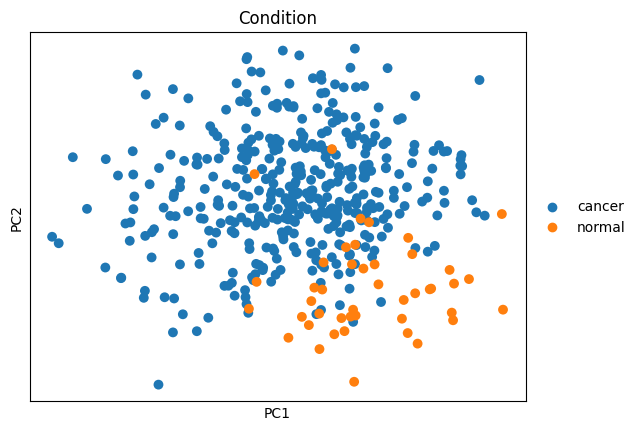

In [ ]:
sc.pl.pca(dds, color = 'Condition', size = 200)